<a href="https://colab.research.google.com/github/mananmalvi/ML--The-Art/blob/main/DAY-21-%F0%9F%9A%80Gradient_Boosting_Classifier_(Practical_implementation_Mini_Project).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAY_21_🚀Gradient_Boosting_Classifier_(Practical_implementation/Mini_Project)

# STEP 1 — Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# STEP 2 — Load the dataset

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True) # convert to DataFrame

df= data.frame.copy()

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# STEP 3 — Basic inspection 🔍

In [3]:
df.shape

(569, 31)

In [4]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [6]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


# STEP 4 — Missing values

In [7]:
df.isnull().sum().sort_values(ascending =True).head(10)

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


# STEP 5 — Duplicate rows

In [8]:
df.duplicated().sum()

np.int64(0)

# STEP 6 — Target distribution

In [9]:
df['target'].value_counts()

,count
target,
1,357
0,212


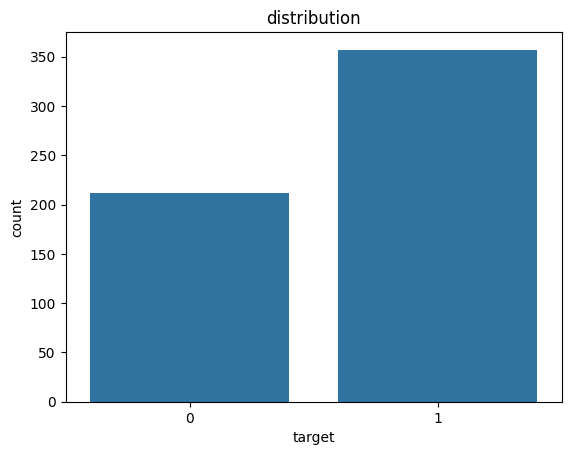

In [10]:
sns.countplot(x= df['target'])
plt.title("distribution")
plt.show()

# STEP 7 — EDA 🧠

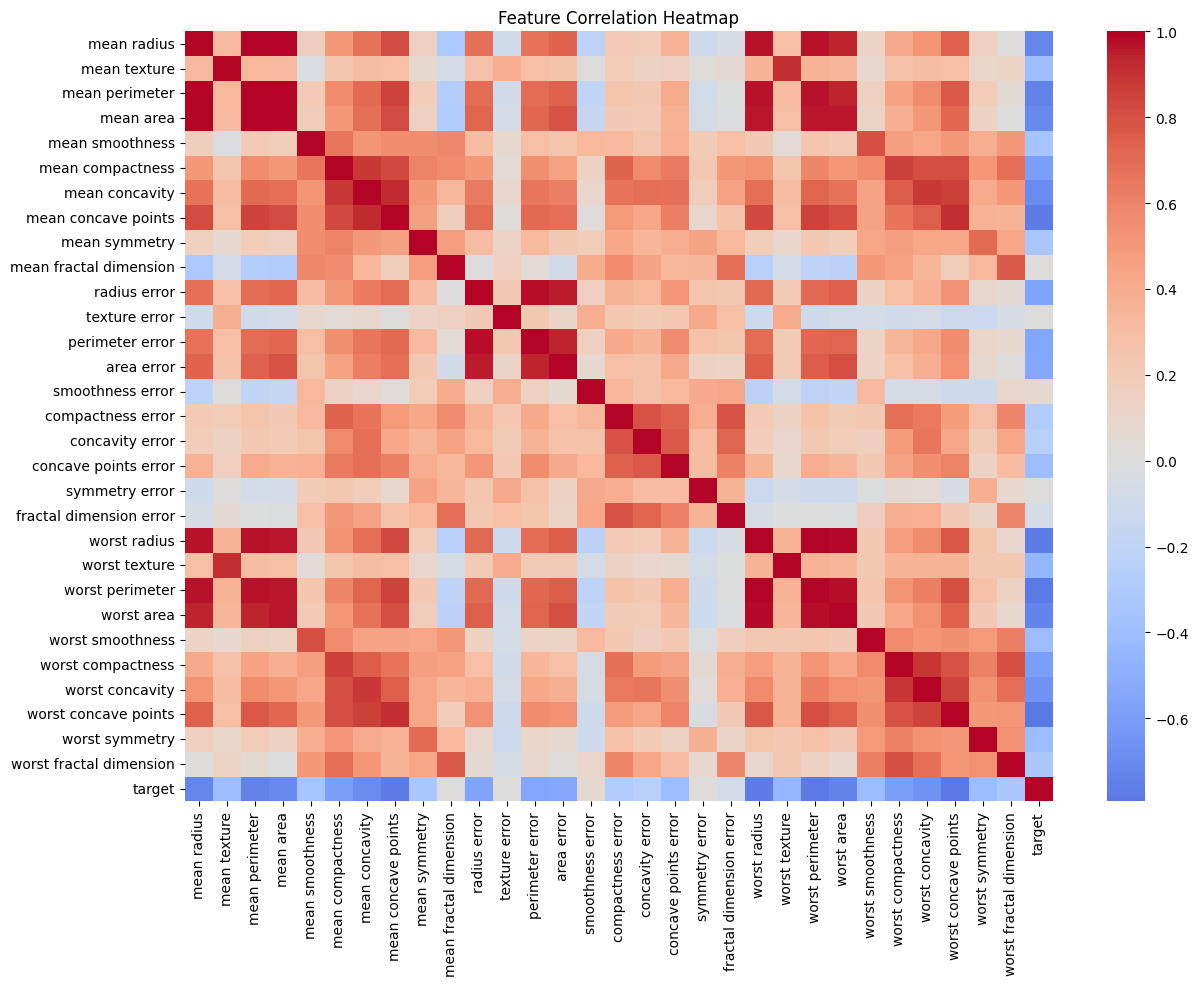

In [11]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

# 🎯 STEP 8 — X vs y

In [12]:
x = df.drop('target',axis=1)
y = df["target"]

# 🚂 STEP 9 — Train/Test Split

In [13]:
x_train,x_test,y_train,y_test = train_test_split(x,y,
                                                 test_size=0.2,
                                                 random_state= 42,
                                                 stratify = y)

# STEP 10 — Is scaling required? ⚠️

This is an important ML-engineering question.

Gradient Boosting trees:

Scaling is NOT required.

Why?

A tree asks questions such as:

radius <= 14.5?

Changing units:

radius = 0.0145 km

doesn't fundamentally change the ordering/splitting logic.

# STEP 11 — Baseline model 🎯

In [14]:
baseline = Pipeline([
                    ("scaler",StandardScaler()),
                    ("model", LogisticRegression(max_iter = 5000))
])

baseline.fit(x_train,y_train)

y_pred_base = baseline.predict(x_test)
y_prob_base = baseline.predict_proba(x_test)[:, 1]


In [15]:
def evaluate_model(name, y_true, y_pred, y_prob):

    print(f"\n{name}")

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_true, y_prob))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

In [16]:
evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_base,
    y_prob_base
)


Logistic Regression
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112
ROC-AUC  : 0.9953703703703703

Confusion Matrix:
[[41  1]
 [ 1 71]]


# STEP 12 — Train Gradient Boosting 🚀

In [17]:
gbc = GradientBoostingClassifier(
                                n_estimators = 100,
                                learning_rate = 0.01,
                                max_depth= 3,
                                subsample=1,
                                min_samples_leaf = 1,
                                min_samples_split = 2,
                                random_state = 42
)

In [18]:
gbc.fit(x_train,y_train)

GradientBoostingClassifier(learning_rate=0.01, random_state=42, subsample=1)

In [19]:
y_pred = gbc.predict(x_test)
y_prob = gbc.predict_proba(x_test)[:, 1]

📊 STEP 12D — Evaluate Gradient Boosting

In [20]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9210526315789473
Precision: 0.9315068493150684
Recall   : 0.9444444444444444
F1 Score : 0.9379310344827586
ROC-AUC  : 0.9623015873015874


# STEP 13 — Confusion Matrix

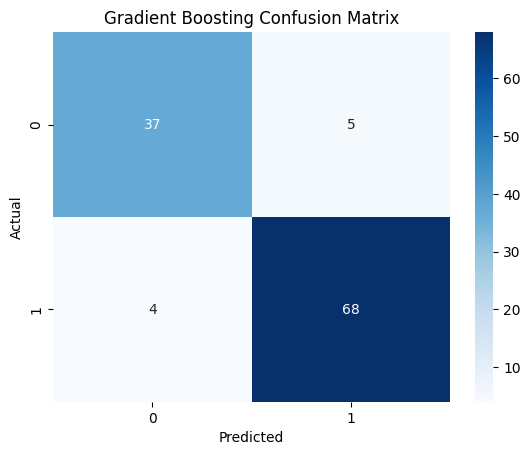

In [21]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

# STEP 14 — Which metric matters here? 🧠⚠️

In [22]:
recall_score(y_test, y_pred)

0.9444444444444444

In [23]:
recall_malignant = recall_score(
    y_test,
    y_pred,
    pos_label=0
)

print(recall_malignant)

0.8809523809523809


# STEP 15 — Hyperparameter tuning 🎛️

In [24]:
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [1, 2, 3],
    "min_samples_leaf": [1, 3],
    "subsample": [0.8, 1.0]
}

# STEP 16 — GridSearchCV

In [25]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits = 5,
                    shuffle = True,
                    random_state = 42)

In [26]:
grid = GridSearchCV( estimator=GradientBoostingClassifier(random_state=42),
                    param_grid=param_grid,
                    scoring='roc_auc',
                    cv=cv,
                    n_jobs=-1
)
# 2*2*2*2*2 = 32
# 32*5 = 160 total models to train

In [27]:
grid.fit(x_train,y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=GradientBoostingClassifier(random_state=42), n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [1, 2, 3],
                         'min_samples_leaf': [1, 3], 'n_estimators': [100, 200],
                         'subsample': [0.8, 1.0]},
             scoring='roc_auc')

# STEP 17 — Evaluate tuned model

In [28]:
best_gb  = grid.best_estimator_
print(best_gb)

GradientBoostingClassifier(learning_rate=0.05, max_depth=2, min_samples_leaf=3,
                           n_estimators=200, random_state=42, subsample=0.8)


In [29]:
best_gb  = grid.best_estimator_

y_pred = best_gb.predict(x_test)
y_prob = best_gb.predict_proba(x_test)[:, 1]

evaluate_model(
    "Tuned Gradient Boosting",
    y_test,
    y_pred,
    y_prob
)


Tuned Gradient Boosting
Accuracy : 0.956140350877193
Precision: 0.9466666666666667
Recall   : 0.9861111111111112
F1 Score : 0.9659863945578231
ROC-AUC  : 0.9920634920634921

Confusion Matrix:
[[38  4]
 [ 1 71]]


#STEP 19 — Feature Importance 🔍

In [31]:
# finding the important feature based
importance = pd.Series(best_gb.feature_importances_,
                       index = x.columns)

importance = importance.sort_values(ascending= False)

importance.head(10)

,0
worst perimeter,0.380529
worst concave points,0.188843
mean concave points,0.142023
worst radius,0.130400
worst area,0.038178
worst texture,0.032509
area error,0.015385
mean texture,0.012331
texture error,0.009720
concavity error,0.007398


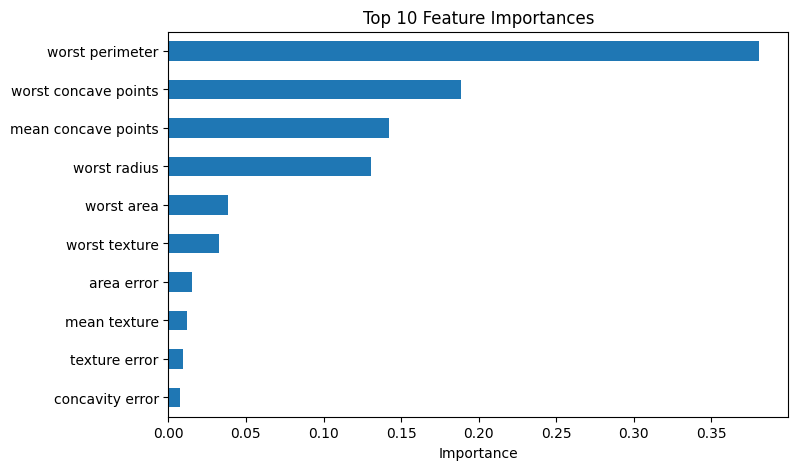

In [32]:
# plotting / visualization

importance.head(10).sort_values().plot(
    kind='barh',
    figsize=(8, 5)
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()

# STEP 20 — Underfitting vs Overfitting 📈

In [33]:
# staged_predict_proba

# In order to find the optimal number of trees, you can use early stopping
# A simple way to implement this is to use the staged_predict()

train_scores = []
test_scores = []

for train_prob, test_prob in zip(
    gbc.staged_predict_proba(x_train),
    gbc.staged_predict_proba(x_test)
):

    train_scores.append(
        roc_auc_score(y_train, train_prob[:, 1])
    )

    test_scores.append(
        roc_auc_score(y_test, test_prob[:, 1])
    )

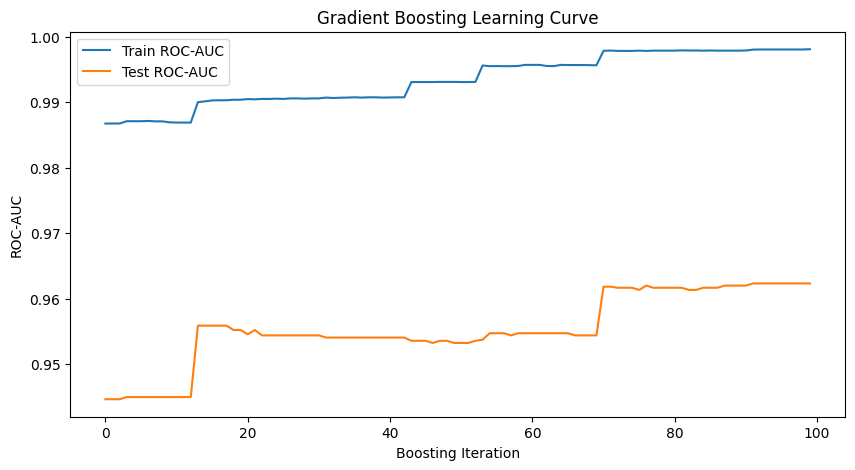

In [34]:
# plotting / visualization

plt.figure(figsize=(10, 5))

plt.plot(train_scores, label='Train ROC-AUC')
plt.plot(test_scores, label='Test ROC-AUC')

plt.xlabel("Boosting Iteration")
plt.ylabel("ROC-AUC")
plt.title("Gradient Boosting Learning Curve")
plt.legend()
plt.show()

# STEP 21 — What if Gradient Boosting performs poorly? ⚠️

Don't immediately switch algorithms.

Debug systematically.

1. Check data quality
missing values
duplicates
incorrect labels
outliers
data leakage
2. Check features

Maybe:

important features missing
bad feature engineering
irrelevant features
3. Tune model complexity

Try:

max_depth ↓
min_samples_leaf ↑
min_samples_split ↑

to reduce overfitting.

4. Adjust learning rate

Try:

learning_rate ↓
n_estimators ↑

Remember:

Smaller steps + more trees.

5. Try stochastic boosting
subsample < 1

This can reduce variance.

6. Compare another model

For example:

Random Forest
XGBoost
HistGradientBoosting
Logistic Regression
SVM

depending on dataset characteristics.

# ⚠️ When NOT to use Gradient Boosting

Don't automatically use it.

Avoid/consider alternatives when:

1. Extremely large dataset

Classic GBC can become computationally expensive.

Consider:

HistGradientBoosting
XGBoost
LightGBM
CatBoost

depending on the environment and data.

2. Highly sparse high-dimensional data

For example certain:

text classification
TF-IDF
bag-of-words

Linear models can be much more appropriate.

3. You need extremely simple interpretability

A:

Logistic Regression

may be easier to explain than hundreds of sequential trees.

4. Real-time ultra-low-latency constraints

A large ensemble may be unnecessarily expensive.

5. Extremely noisy / tiny dataset

Boosting can chase noise if regularization and validation aren't handled carefully.